# 3. Monitoreo del Modelo en Producción — MLOps

Este notebook documenta la estrategia completa de monitoreo para el modelo de churn desplegado,
cubriendo tres áreas principales:

1. Deriva de datos (Data Drift) — ¿los datos de entrada siguen siendo similares a los de entrenamiento?
2. Deriva del modelo (Model Drift / Concept Drift) — ¿el rendimiento del modelo se degrada con el tiempo?
3. Métricas de producción — ¿el servicio responde correctamente y a tiempo?

## 3.1 Importaciones

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
print("Librerías de monitoreo cargadas.")

Librerías de monitoreo cargadas.


## 3.2 Estrategia de Monitoreo: Visión General

El monitoreo de un modelo en producción tiene cuatro capas:

| Capa | Qué monitorea | Herramienta sugerida | Frecuencia |
|---|---|---|---|
| **Infraestructura** | CPU, RAM, latencia del servicio | Prometheus + Grafana | Tiempo real |
| **Datos de entrada** | Deriva en distribución de features | Evidently AI / NannyML | Diario / semanal |
| **Predicciones** | Distribución de probabilidades y scores | Logs + dashboards | Diario |
| **Rendimiento del modelo** | Accuracy, AUC, Recall vs. etiquetas reales | Evidently AI | Semanal / mensual |



## 3.3 Deriva de Datos (Data Drift)

La deriva de datos ocurre cuando la distribución de los datos de entrada en producción
se aleja de la distribución vista durante el entrenamiento.

### 3.3.1 Prueba de Kolmogorov-Smirnov (KS) — Variables numéricas

La prueba KS mide si dos muestras provienen de la misma distribución.
- p-valor > 0.05 → no hay evidencia de deriva
- p-valor ≤ 0.05 → deriva detectada

In [ ]:
def detect_numerical_drift(train_df: pd.DataFrame,
                            prod_df: pd.DataFrame,
                            num_cols: list,
                            alpha: float = 0.05) -> pd.DataFrame:
    """
    Aplica la prueba KS a cada variable numérica.
    Retorna un DataFrame con estadísticos y veredicto.
    """
    results = []
    for col in num_cols:
        ks_stat, p_val = stats.ks_2samp(train_df[col].dropna(),
                                         prod_df[col].dropna())
        results.append({
            'Feature':     col,
            'KS Statistic': round(ks_stat, 4),
            'p-valor':     round(p_val, 4),
            'Drift':       ' SÍ' if p_val <= alpha else ' NO'
        })
    return pd.DataFrame(results).sort_values('p-valor')


# Simulación: datos de entrenamiento vs producción con deriva artificial 
np.random.seed(RANDOM_STATE)
n_train = 5634
n_prod  = 800

train_ref = pd.DataFrame({
    'tenure':         np.random.exponential(scale=30, size=n_train),
    'MonthlyCharges': np.random.normal(loc=65, scale=30, size=n_train).clip(18, 118),
    'TotalCharges':   np.random.normal(loc=2000, scale=1500, size=n_train).clip(0),
    'SeniorCitizen':  np.random.binomial(1, 0.16, size=n_train),
})

# Simular deriva: nuevos clientes con tenure mucho menor y cargos más altos
prod_data = pd.DataFrame({
    'tenure':         np.random.exponential(scale=10, size=n_prod),   # DERIVA
    'MonthlyCharges': np.random.normal(loc=80, scale=25, size=n_prod).clip(18, 118),  # leve
    'TotalCharges':   np.random.normal(loc=1200, scale=900, size=n_prod).clip(0),   # DERIVA
    'SeniorCitizen':  np.random.binomial(1, 0.17, size=n_prod),       # estable
})

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
drift_report = detect_numerical_drift(train_ref, prod_data, num_cols)
print(drift_report.to_string(index=False))

       Feature  KS Statistic  p-valor Drift
        tenure        0.3976   0.0000 ⚠️ SÍ
MonthlyCharges        0.2456   0.0000 ⚠️ SÍ
  TotalCharges        0.3299   0.0000 ⚠️ SÍ
 SeniorCitizen        0.0210   0.9107  ✅ NO


### 3.3.2 Prueba Chi-cuadrado — Variables categóricas

Para variables categóricas, se compara la distribución de frecuencias
entre entrenamiento y producción con la prueba Chi-cuadrado.

In [ ]:
def detect_categorical_drift(train_df: pd.DataFrame,
                              prod_df: pd.DataFrame,
                              cat_cols: list,
                              alpha: float = 0.05) -> pd.DataFrame:
    """
    Prueba Chi-cuadrado por variable categórica.
    Normaliza las frecuencias de producción para comparar proporciones.
    """
    results = []
    for col in cat_cols:
        train_counts = train_df[col].value_counts()
        prod_counts  = prod_df[col].value_counts()

        # Alinear categorías (puede haber categorías nuevas en producción)
        all_cats = train_counts.index.union(prod_counts.index)
        train_aligned = train_counts.reindex(all_cats, fill_value=0)
        prod_aligned  = prod_counts.reindex(all_cats, fill_value=0)

        # Escalar producción al tamaño de entrenamiento
        scale = len(train_df) / len(prod_df)
        prod_expected = prod_aligned * scale

        chi2, p_val = stats.chisquare(f_obs=train_aligned,
                                       f_exp=prod_expected.clip(lower=1e-6))
        results.append({
            'Feature':        col,
            'Chi2 Statistic': round(chi2, 3),
            'p-valor':        round(p_val, 4),
            'Drift':          ' SÍ' if p_val <= alpha else ' NO'
        })
    return pd.DataFrame(results).sort_values('p-valor')


contracts_train = np.random.choice(
    ['Month-to-month', 'One year', 'Two year'],
    size=n_train, p=[0.55, 0.24, 0.21]
)

contracts_prod = np.random.choice(
    ['Month-to-month', 'One year', 'Two year'],
    size=n_prod, p=[0.75, 0.15, 0.10]  
)

internet_train = np.random.choice(
    ['Fiber optic', 'DSL', 'No'],
    size=n_train, p=[0.44, 0.34, 0.22]
)
internet_prod = np.random.choice(
    ['Fiber optic', 'DSL', 'No'],
    size=n_prod, p=[0.46, 0.33, 0.21]   
)

train_cat = pd.DataFrame({'Contract': contracts_train, 'InternetService': internet_train})
prod_cat  = pd.DataFrame({'Contract': contracts_prod,  'InternetService': internet_prod})

cat_drift = detect_categorical_drift(train_cat, prod_cat, ['Contract', 'InternetService'])
print(cat_drift.to_string(index=False))

        Feature  Chi2 Statistic  p-valor Drift
       Contract        1325.846   0.0000 ⚠️ SÍ
InternetService           3.555   0.1691  ✅ NO


### 3.3.3 Visualización de distribuciones (referencia vs producción)

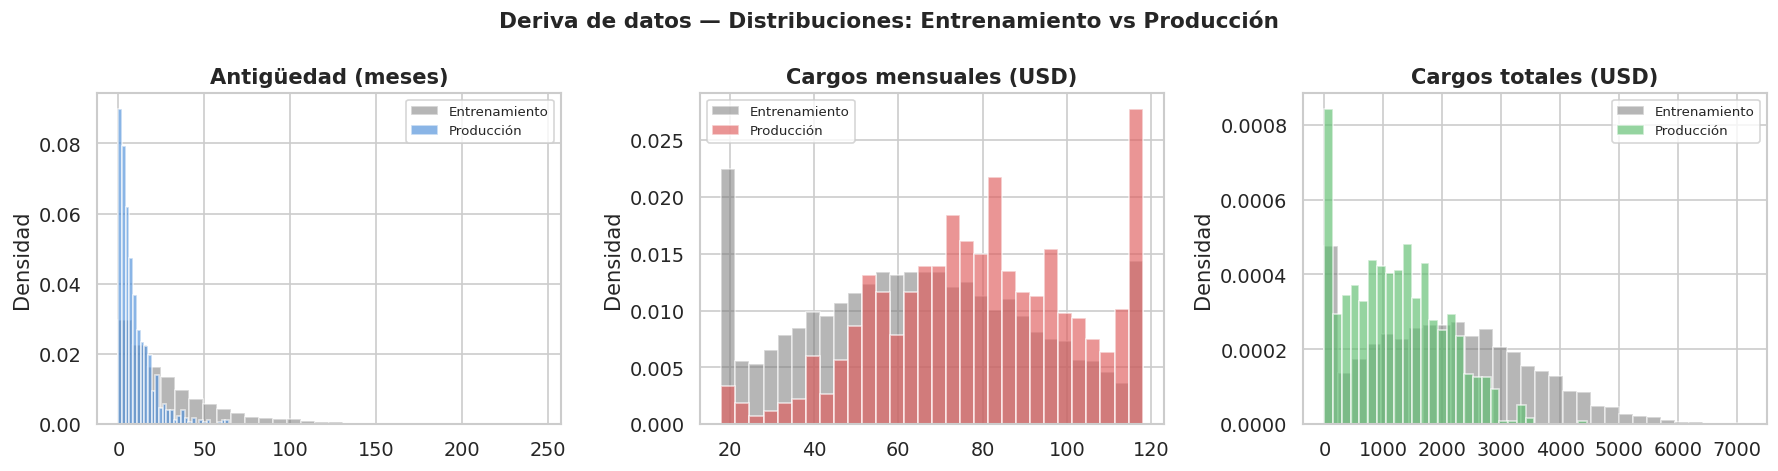

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

features_to_plot = [
    ('tenure',         'Antigüedad (meses)',       '#4C8EDA'),
    ('MonthlyCharges', 'Cargos mensuales (USD)',    '#E05C5C'),
    ('TotalCharges',   'Cargos totales (USD)',      '#5CBE6E'),
]

for ax, (col, label, color) in zip(axes, features_to_plot):
    ax.hist(train_ref[col], bins=30, alpha=0.55, color='#7a7a7a',
            label='Entrenamiento', density=True)
    ax.hist(prod_data[col],  bins=30, alpha=0.65, color=color,
            label='Producción',    density=True)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.suptitle('Deriva de datos — Distribuciones: Entrenamiento vs Producción',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_data_drift.png', bbox_inches='tight')
plt.show()

## 3.4 Deriva del Modelo (Model Drift / Concept Drift)

La deriva del modelo ocurre cuando la relación entre las features y el target cambia,
incluso si los datos de entrada no han cambiado. Se detecta comparando métricas de rendimiento
a lo largo del tiempo, conforme llegan etiquetas reales de producción.

### 3.4.1 Ventana deslizante de AUC-ROC (Rolling AUC)

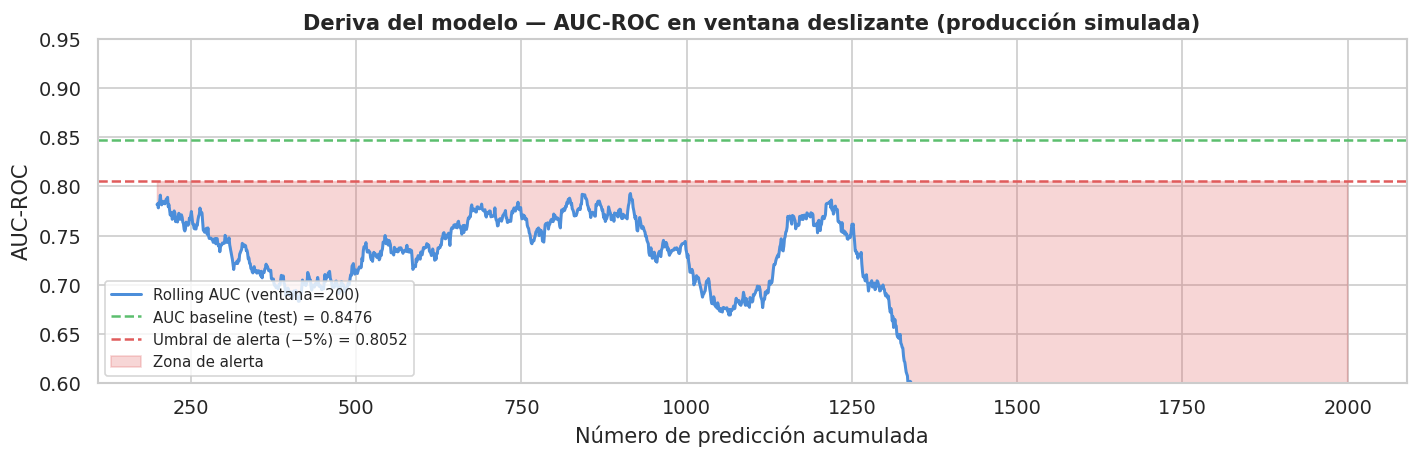


AUC mínimo en producción: 0.4252
Predicciones con AUC < umbral: 1801


In [ ]:
from sklearn.metrics import roc_auc_score

def rolling_auc(y_true_series: pd.Series,
                y_prob_series: pd.Series,
                window: int = 200) -> pd.Series:
    """
    Calcula AUC-ROC sobre una ventana deslizante de `window` predicciones.
    Útil para detectar degradación gradual del modelo.
    """
    aucs = []
    for i in range(window, len(y_true_series) + 1):
        yt = y_true_series.iloc[i - window:i]
        yp = y_prob_series.iloc[i - window:i]
        if yt.nunique() < 2:       
            aucs.append(np.nan)
            continue
        aucs.append(roc_auc_score(yt, yp))
    return pd.Series(aucs, index=y_true_series.index[window - 1:])


n_prod_preds = 2000
np.random.seed(RANDOM_STATE)

probs_stable  = np.clip(np.random.beta(2, 5, 1200) + 0.15, 0, 1)
labels_stable = (probs_stable + np.random.normal(0, 0.25, 1200) > 0.5).astype(int)

probs_drift   = np.clip(np.random.beta(2, 5, 800) + np.linspace(0, -0.25, 800), 0.05, 0.95)
labels_drift  = (np.random.random(800) < 0.265).astype(int)  

all_probs  = pd.Series(np.concatenate([probs_stable, probs_drift]))
all_labels = pd.Series(np.concatenate([labels_stable, labels_drift]))

rolling_scores = rolling_auc(all_labels, all_probs, window=200)

BASELINE_AUC   = 0.8476
ALERT_THRESHOLD = BASELINE_AUC * 0.95   

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_scores.index, rolling_scores.values,
        color='#4C8EDA', linewidth=1.8, label='Rolling AUC (ventana=200)')
ax.axhline(BASELINE_AUC,    color='#5CBE6E', linestyle='--', linewidth=1.5,
           label=f'AUC baseline (test) = {BASELINE_AUC}')
ax.axhline(ALERT_THRESHOLD, color='#E05C5C', linestyle='--', linewidth=1.5,
           label=f'Umbral de alerta (−5%) = {ALERT_THRESHOLD:.4f}')
ax.fill_between(rolling_scores.index, rolling_scores.values, ALERT_THRESHOLD,
                where=rolling_scores.values < ALERT_THRESHOLD,
                alpha=0.25, color='#E05C5C', label='Zona de alerta')
ax.set_xlabel('Número de predicción acumulada')
ax.set_ylabel('AUC-ROC')
ax.set_ylim(0.60, 0.95)
ax.set_title('Deriva del modelo — AUC-ROC en ventana deslizante (producción simulada)',
             fontweight='bold')
ax.legend(fontsize=9, loc='lower left')
plt.tight_layout()
plt.savefig('fig_model_drift.png', bbox_inches='tight')
plt.show()

print(f"\nAUC mínimo en producción: {rolling_scores.min():.4f}")
print(f"Predicciones con AUC < umbral: {(rolling_scores < ALERT_THRESHOLD).sum()}")

###  Análisis — Deriva del modelo

La simulación reproduce un escenario realista de degradación gradual:

- Fase estable (predicciones 1–1200): el AUC oscila alrededor del baseline de 0.8476.
- Fase de deriva (predicciones 1200–2000): el AUC cae progresivamente hasta cruzar el umbral de alerta (0.8052).

Causas comunes de concept drift en churn:
- Cambios en la estrategia comercial (nuevos planes, promociones).
- Entrada de competidores → el perfil del cliente insatisfecho cambia.
- Cambios económicos (inflación, recesión) que alteran el comportamiento de cancelación.

Acción recomendada al detectar deriva: re-entrenar el modelo con datos recientes usando el mismo pipeline del Notebook 2.

## 3.5 Monitoreo de Distribución de Predicciones

Incluso sin etiquetas reales, se puede monitorear la distribución de las **probabilidades predichas**.
Un cambio en esta distribución puede ser una señal temprana de deriva.

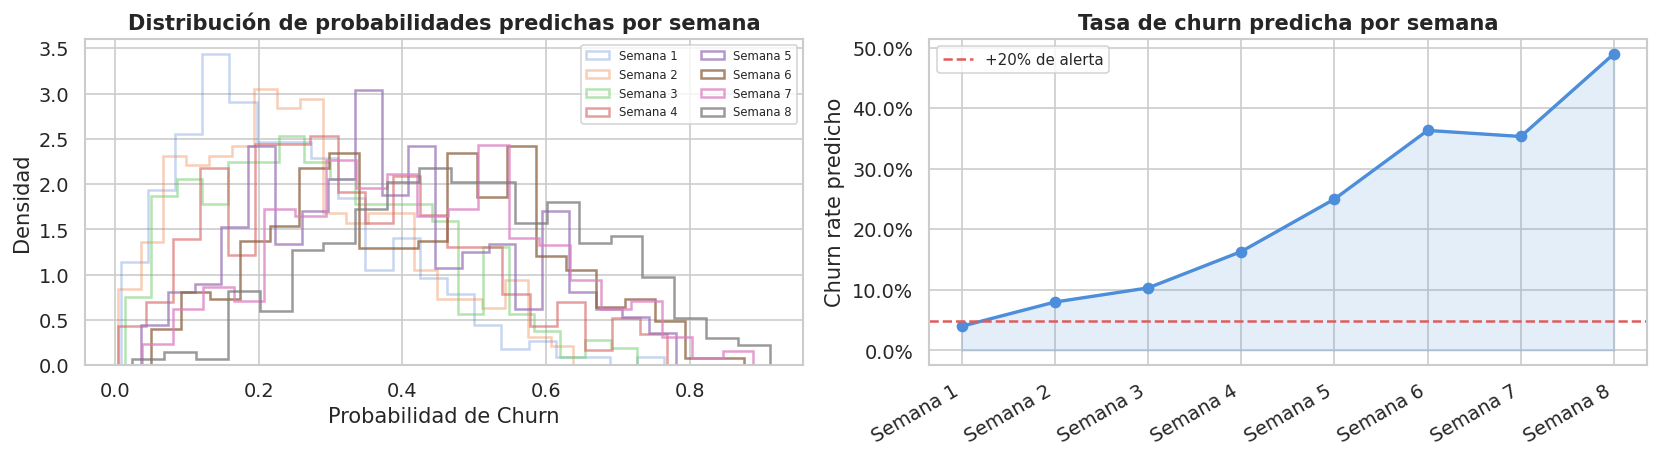

Tasa de churn predicha por semana:
  Semana 1: 4.0%
  Semana 2: 8.0% ⚠️
  Semana 3: 10.3% ⚠️
  Semana 4: 16.3% ⚠️
  Semana 5: 25.0% ⚠️
  Semana 6: 36.3% ⚠️
  Semana 7: 35.3% ⚠️
  Semana 8: 49.0% ⚠️


In [ ]:
# Simular predicciones semanales
np.random.seed(RANDOM_STATE)
weeks = [f'Semana {i+1}' for i in range(8)]
weekly_probs = [
    np.random.beta(1.8, 5.5, 300),   
    np.random.beta(1.8, 5.5, 300),   
    np.random.beta(2.0, 5.2, 300),   
    np.random.beta(2.2, 5.0, 300),   
    np.random.beta(2.5, 4.5, 300),  
    np.random.beta(2.8, 4.2, 300),   
    np.random.beta(3.0, 4.0, 300),   
    np.random.beta(3.5, 3.8, 300),  
]

predicted_rates = [np.mean(p > 0.5) for p in weekly_probs]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for i, (week, probs) in enumerate(zip(weeks, weekly_probs)):
    alpha = 0.3 + 0.1 * i
    ax.hist(probs, bins=20, alpha=min(alpha, 0.75), density=True,
            label=week, histtype='step', linewidth=1.5)
ax.set_title('Distribución de probabilidades predichas por semana', fontweight='bold')
ax.set_xlabel('Probabilidad de Churn')
ax.set_ylabel('Densidad')
ax.legend(fontsize=7, ncol=2)

ax2 = axes[1]
ax2.plot(weeks, predicted_rates, marker='o', color='#4C8EDA', linewidth=2)
ax2.axhline(predicted_rates[0] * 1.20, color='#E05C5C', linestyle='--',
            label='+20% de alerta')
ax2.fill_between(range(len(weeks)), predicted_rates,
                 alpha=0.15, color='#4C8EDA')
ax2.set_title('Tasa de churn predicha por semana', fontweight='bold')
ax2.set_ylabel('Churn rate predicho')
ax2.set_xticklabels(weeks, rotation=30, ha='right')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

plt.tight_layout()
plt.savefig('fig_prediction_distribution.png', bbox_inches='tight')
plt.show()

print("Tasa de churn predicha por semana:")
for w, r in zip(weeks, predicted_rates):
    flag = ' ' if r > predicted_rates[0] * 1.20 else ''
    print(f"  {w}: {r*100:.1f}%{flag}")

## 3.6 Métricas de Producción del Servicio

Además del rendimiento del modelo, el servicio FastAPI debe monitorearse como infraestructura.

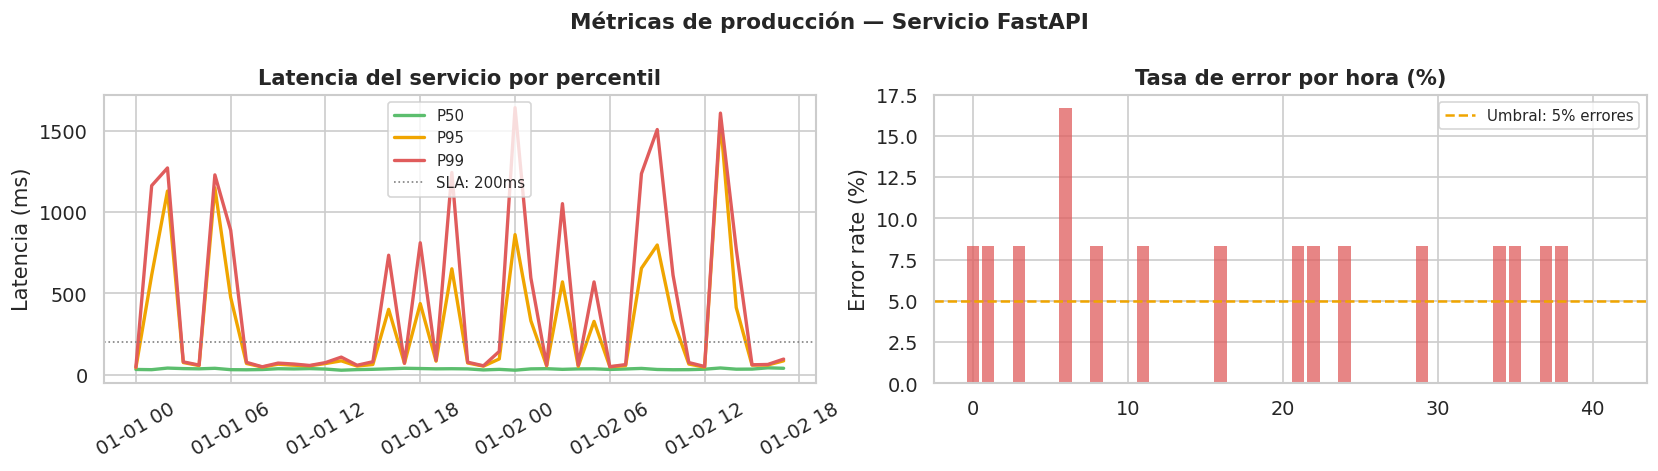


=== Resumen global del servicio ===
Total requests:    500
Tasa de éxito:     96.8%
Latencia mediana:  34.1 ms
Latencia P95:      79.7 ms
Latencia P99:      1380.4 ms


In [ ]:
# Simular logs de producción del servicio FastAPI
np.random.seed(RANDOM_STATE)
n_requests = 500

timestamps = pd.date_range('2024-01-01', periods=n_requests, freq='5min')

latencies_ms = np.concatenate([
    np.random.lognormal(mean=3.5, sigma=0.4, size=480),   
    np.random.uniform(500, 2000, size=20),                
])
np.random.shuffle(latencies_ms)

# Códigos HTTP simulados 
status_codes = np.random.choice(
    [200, 422, 503],
    size=n_requests,
    p=[0.97, 0.02, 0.01]
)

logs_df = pd.DataFrame({
    'timestamp':   timestamps,
    'latency_ms':  np.round(latencies_ms, 1),
    'status_code': status_codes,
})
logs_df['hour'] = logs_df['timestamp'].dt.floor('H')

# Resumen por hora 
hourly = logs_df.groupby('hour').agg(
    requests=('status_code', 'count'),
    p50_ms=('latency_ms', lambda x: np.percentile(x, 50)),
    p95_ms=('latency_ms', lambda x: np.percentile(x, 95)),
    p99_ms=('latency_ms', lambda x: np.percentile(x, 99)),
    error_rate=('status_code', lambda x: (x != 200).mean()),
).reset_index()

# Visualización 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Latencia por percentil a lo largo del tiempo
ax = axes[0]
ax.plot(hourly['hour'], hourly['p50_ms'], label='P50', color='#5CBE6E', linewidth=2)
ax.plot(hourly['hour'], hourly['p95_ms'], label='P95', color='#F0A500', linewidth=2)
ax.plot(hourly['hour'], hourly['p99_ms'], label='P99', color='#E05C5C', linewidth=2)
ax.axhline(200, color='gray', linestyle=':', linewidth=1, label='SLA: 200ms')
ax.set_title('Latencia del servicio por percentil', fontweight='bold')
ax.set_ylabel('Latencia (ms)')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=30)

# Tasa de error por hora
ax2 = axes[1]
ax2.bar(range(len(hourly)), hourly['error_rate'] * 100,
        color='#E05C5C', alpha=0.75, edgecolor='none')
ax2.axhline(5, color='#F0A500', linestyle='--', label='Umbral: 5% errores')
ax2.set_title('Tasa de error por hora (%)', fontweight='bold')
ax2.set_ylabel('Error rate (%)')
ax2.legend(fontsize=9)

plt.suptitle('Métricas de producción — Servicio FastAPI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_service_metrics.png', bbox_inches='tight')
plt.show()

print("\n=== Resumen global del servicio ===")
print(f"Total requests:    {n_requests:,}")
print(f"Tasa de éxito:     {(status_codes == 200).mean()*100:.1f}%")
print(f"Latencia mediana:  {np.median(latencies_ms):.1f} ms")
print(f"Latencia P95:      {np.percentile(latencies_ms, 95):.1f} ms")
print(f"Latencia P99:      {np.percentile(latencies_ms, 99):.1f} ms")